# 🚦 Segurança Viária — PRF Pará 2024–2025
## Notebook 02 · Modelagem Estatística Avançada

**Autor:** Gilson Machado — Cientista de Dados | Pós-Graduação em Estatística Aplicada à Ciência de Dados  
**Pré-requisito:** Notebook 01 executado e `df_pa_final.parquet` salvo no Drive

---

| Seção | Método | Justificativa |
|-------|--------|---------------|
| 1 | Carga e preparação | Leitura do parquet + features adicionais |
| 2 | **Regressão Logística Ordinal** | Desfecho em 4 níveis — mais informativo que binário |
| 3 | **Modelo Multinível (GLMM)** | ICC 14–16% entre BRs/municípios — erros correlacionados |
| 4 | **Hotspot Inferencial por Trecho** | Trechos críticos com significância estatística |
| 5 | Classificador Calibrado (XGBoost) | Predição + SHAP + Brier Score |
| 6 | Resumo consolidado | Tabela de resultados por eixo |

> *Eixo inferencial principal: Seções 2, 3 e 4. Seção 5 é complemento preditivo.*


---
## 1. Carga e Preparação


In [1]:
# ── 1.1  DEPENDÊNCIAS ──────────────────────────────────────────────────────────
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("⚠️  Drive indisponível:", e)

# Instalar pacotes extras necessários
import subprocess
subprocess.run(["pip","install","statsmodels","xgboost","shap",
                "--quiet","--upgrade"], check=False)


Mounted at /content/drive


CompletedProcess(args=['pip', 'install', 'statsmodels', 'xgboost', 'shap', '--quiet', '--upgrade'], returncode=0)

In [2]:
# ── 1.2  CARREGAR PARQUET ──────────────────────────────────────────────────────
path = "/content/drive/MyDrive/ppgme_datatran/df_pa_final.parquet"
df = pd.read_parquet(path)

print(f"✅ Base carregada: {df.shape[0]:,} linhas | {df.shape[1]} colunas")
print(f"   Período: {df['data_inversa'].min().date()} → {df['data_inversa'].max().date()}")
print(f"   Fatal: {df['is_fatal'].mean()*100:.2f}%  ({df['is_fatal'].sum():,} acidentes)")
print()
# Verificar colunas essenciais
essenciais = ["severidade","is_fatal","tracado_simples","uso_solo",
              "br","municipio","causa_acidente","tipo_acidente",
              "fase_dia","tipo_pista","condicao_metereologica","dia_semana"]
faltando = [c for c in essenciais if c not in df.columns]
if faltando:
    raise ValueError(f"Colunas ausentes — rode o Notebook 01 primeiro: {faltando}")
print("✅ Todas as colunas essenciais presentes")


✅ Base carregada: 1,977 linhas | 42 colunas
   Período: 2024-01-01 → 2025-11-30
   Fatal: 18.21%  (360 acidentes)

✅ Todas as colunas essenciais presentes


In [3]:
# ── 1.3  FEATURES ADICIONAIS PARA MODELAGEM ───────────────────────────────────
# Garantir tipos
for c in ["causa_acidente","tipo_acidente","fase_dia",
          "condicao_metereologica","tipo_pista","uso_solo",
          "dia_semana","tracado_simples","br","municipio"]:
    df[c] = df[c].astype(str)

# uso_solo binário (Rural=1, Urbano=0)
df["rural"] = (df["uso_solo"] == "Não").astype(int)

# Noite/madrugada
df["noite_madrugada"] = df["hora_num"].apply(
    lambda h: 1 if (h >= 18 or h < 6) else 0)

# BR como string limpa (grupo para multinível)
df["br_str"] = "BR-" + df["br"].astype(str).str.strip()

# Distribuição final
SEV_LABEL = {0:"Sem vítimas",1:"Feridos leves",2:"Feridos graves",3:"Fatal"}
print("Distribuição de severidade (variável-resposta ordinal):")
for k, v in df["severidade"].value_counts().sort_index().items():
    print(f"  {k} — {SEV_LABEL[k]}: {v:,} ({v/len(df)*100:.1f}%)")


Distribuição de severidade (variável-resposta ordinal):
  0 — Sem vítimas: 384 (19.4%)
  1 — Feridos leves: 742 (37.5%)
  2 — Feridos graves: 491 (24.8%)
  3 — Fatal: 360 (18.2%)


---
## 2. Regressão Logística Ordinal

**Por que ordinal?** O desfecho tem 4 níveis naturais ordenados: Sem vítimas (0) → Feridos leves (1) → Graves (2) → Fatal (3).  
Dicotomizar em fatal/não-fatal descarta 60% da informação de severidade.

**Modelo:** Logit proporcional cumulativo (Proportional Odds Model — POM).  
Para cada preditor $x$, um único OR estima a chance de estar em um nível *mais grave* vs *igual ou menos grave*.

**Verificação:** Teste de proporcionalidade (Brant) — se violado, ajusta-se modelo de odds parciais.

> *OR > 1 = aumenta chance de severidade mais grave. OR < 1 = reduz.*


In [4]:
# ── 2.1  INSTALAR E IMPORTAR mord (Ordinal Regression) ────────────────────────
try:
    from mord import LogisticIT
    print("✅ mord disponível")
except ImportError:
    import subprocess
    subprocess.run(["pip","install","mord","--quiet"], check=False)
    from mord import LogisticIT
    print("✅ mord instalado e importado")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


✅ mord instalado e importado


In [5]:
# ── 2.2  REGRESSÃO ORDINAL VIA STATSMODELS (OrderedModel) ─────────────────────
# OrderedModel implementa POM diretamente com IC95% e p-valores
from statsmodels.miscmodels.ordinal_model import OrderedModel

features_ord = ["causa_acidente","tipo_acidente","fase_dia",
                "condicao_metereologica","tipo_pista",
                "tracado_simples","uso_solo","dia_semana"]

df_ord = df.dropna(subset=features_ord + ["severidade"]).copy()
for c in features_ord:
    df_ord[c] = df_ord[c].astype(str)

# Desfecho como Categorical ordenado
df_ord["sev_ord"] = pd.Categorical(
    df_ord["severidade"].map(SEV_LABEL),
    categories=["Sem vítimas","Feridos leves","Feridos graves","Fatal"],
    ordered=True
)

formula_ord = "sev_ord ~ " + " + ".join([f"C({c})" for c in features_ord])

mod_ord = OrderedModel.from_formula(
    formula_ord, data=df_ord, distr="logit"
).fit(method="bfgs", disp=False)

print("✅ Modelo ordinal ajustado (Proportional Odds — logit)")
print(f"   N observações: {len(df_ord):,}")
print(f"   Log-Likelihood: {mod_ord.llf:.2f}")
print(f"   AIC: {mod_ord.aic:.2f}")
print()
display(mod_ord.summary())


✅ Modelo ordinal ajustado (Proportional Odds — logit)
   N observações: 1,977
   Log-Likelihood: -2384.36
   AIC: 4958.73



<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                sev_ord   Log-Likelihood:                -2384.4
Model:                   OrderedModel   AIC:                             4959.
Method:            Maximum Likelihood   BIC:                             5490.
Date:                Tue, 19 May 2026                                         
Time:                        19:32:12                                         
No. Observations:                1977                                         
Df Residuals:                    1882                                         
Df Model:                          92                                         
=============================================================================================================================================================
                                                                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------------------------
C(causa_acidente)[T.Acesso irregular]                                                        -0.1215      0.517     -0.235      0.814      -1.135       0.892
C(causa_acidente)[T.Acostamento em desnível]                                                 -0.2396      0.508     -0.472      0.637      -1.235       0.756
C(causa_acidente)[T.Acumulo de areia ou detritos sobre o pavimento]                          -1.5683      0.834     -1.882      0.060      -3.202       0.065
C(causa_acidente)[T.Acumulo de água sobre o pavimento]                                       -0.1042      0.712     -0.146      0.884      -1.500       1.291
C(causa_acidente)[T.Acumulo de óleo sobre o pavimento]                                      -10.1428     92.178     -0.110      0.912    -190.809     170.523
C(causa_acidente)[T.Afundamento ou ondulação no pavimento]                                   -0.3654      1.161     -0.315      0.753      -2.641       1.910
C(causa_acidente)[T.Animais na Pista]                                                        -0.1587      0.601     -0.264      0.792      -1.336       1.019
C(causa_acidente)[T.Ausência de reação do condutor]                                           0.1479      0.193      0.767      0.443      -0.230       0.526
C(causa_acidente)[T.Ausência de sinalização]                                                 -0.5064      0.952     -0.532      0.595      -2.372       1.359
C(causa_acidente)[T.Avarias e/ou desgaste excessivo no pneu]                                  0.2745      0.387      0.710      0.478      -0.484       1.033
C(causa_acidente)[T.Carga excessiva e/ou mal acondicionada]                                  -1.0677      0.594     -1.797      0.072      -2.232       0.097
C(causa_acidente)[T.Chuva]                                                                   -0.1380      0.973     -0.142      0.887      -2.046       1.770
C(causa_acidente)[T.Condutor Dormindo]                                                       -0.1614      0.370     -0.436      0.663      -0.886       0.563
C(causa_acidente)[T.Condutor deixou de manter distância do veículo da frente]                -0.4289      0.290     -1.479      0.139      -0.997       0.139
C(causa_acidente)[T.Condutor desrespeitou a iluminação vermelha do semáforo]                 -0.9329      0.555     -1.682      0.093      -2.020       0.154
C(causa_acidente)[T.Condutor usando celular]                                                 -2.8632      1.194     -2.397      0.017      -5.204      -0.522
C(causa_acidente)[T.Conversão proibida]                                                       0.1925      0.309      0.622      0.534      -0.414       0.799
C(

In [6]:
# ── 2.3  OR CUMULATIVOS COM IC95% — TABELA PUBLICÁVEL ─────────────────────────
params  = mod_ord.params
pvalues = mod_ord.pvalues
conf    = mod_ord.conf_int()
conf.columns = ["ci_low","ci_high"]

tabela_ord = pd.DataFrame({
    "variavel":  params.index,
    "coef":      params.values,
    "p_valor":   pvalues.values,
    "OR":        np.exp(params.values),
    "IC95_low":  np.exp(conf["ci_low"].values),
    "IC95_high": np.exp(conf["ci_high"].values),
})

# Remover limiares (thresholds do modelo ordinal)
tabela_ord = tabela_ord[~tabela_ord["variavel"].str.contains(
    "Sem vítimas|Feridos|Fatal", na=False)].copy()

# Função para extrair col/val de termos C(col)[T.val]
def extrair_col_val(term):
    if term.startswith("C(") and ")[T." in term:
        col = term.split("C(")[1].split(")")[0]
        val = term.split("[T.")[1].rstrip("]")
        return col, val
    return None, None

# Frequência por categoria
n_list = []
for term in tabela_ord["variavel"]:
    col, val = extrair_col_val(term)
    n_list.append(int((df_ord[col].astype(str) == val).sum())
                  if col else np.nan)
tabela_ord["n"] = n_list

MIN_N = 20
tabela_ord = tabela_ord[tabela_ord["n"].fillna(0) >= MIN_N].copy()
tabela_ord["dist"] = np.log(tabela_ord["OR"]).abs()
tabela_ord = tabela_ord.sort_values("dist", ascending=False).drop(columns="dist")

tabela_sig_ord = tabela_ord[tabela_ord["p_valor"] < 0.05].copy()

def nome_amigavel(term):
    col, val = extrair_col_val(term)
    mapa = {
        "causa_acidente":"Causa","tipo_acidente":"Tipo",
        "fase_dia":"Fase do dia","condicao_metereologica":"Cond. meteorológica",
        "dia_semana":"Dia da semana","tipo_pista":"Tipo de pista",
        "tracado_simples":"Traçado","uso_solo":"Uso do solo"
    }
    return f"{mapa.get(col,col)}: {val}" if col else term

tabela_sig_ord["Variável"] = tabela_sig_ord["variavel"].apply(nome_amigavel)
tabela_sig_ord["OR (IC95%)"] = tabela_sig_ord.apply(
    lambda r: f"{r['OR']:.2f} ({r['IC95_low']:.2f}–{r['IC95_high']:.2f})", axis=1)
tabela_sig_ord["p"] = tabela_sig_ord["p_valor"].apply(lambda x: f"{x:.4f}")

print(f"📋 OR Cumulativos — Efeitos com p<0,05 e n≥{MIN_N}: {len(tabela_sig_ord)}")
print("OR > 1 = aumenta chance de severidade mais grave")
display(tabela_sig_ord[["Variável","OR (IC95%)","p","n"]]
        .sort_values("p").head(20))


📋 OR Cumulativos — Efeitos com p<0,05 e n≥20: 13
OR > 1 = aumenta chance de severidade mais grave


,Variável,OR (IC95%),p,n
65,Tipo: Incêndio,0.03 (0.01–0.17),0.0001,46
33,Causa: Ingestão de álcool pelo condutor,0.50 (0.31–0.82),0.0063,100
57,Tipo: Colisão frontal,4.94 (1.52–16.03),0.0077,273
71,Fase do dia: Pleno dia,0.60 (0.41–0.88),0.0095,1034
83,Traçado: Outro,0.35 (0.15–0.78),0.0109,21
49,Causa: Transitar na contramão,1.83 (1.15–2.92),0.0110,162
79,Tipo de pista: Simples,1.34 (1.06–1.68),0.0130,1514
89,Dia da semana: sexta-feira,0.69 (0.51–0.93),0.0139,298
54,Tipo: Atropelamento de Pedestre,5.21 (1.35–20.13),0.0167,63
77,Cond. meteorológica: Sol,1.71 (1.04–2.82),0.0351,124


In [13]:
# ── 2.4  FOREST PLOT DOS OR CUMULATIVOS ───────────────────────────────────────
import plotly.graph_objects as go

t = tabela_sig_ord.sort_values("OR", ascending=True).head(20)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=t["OR"], y=t["Variável"],
    mode="markers",
    marker=dict(size=9, color=["#E74C3C" if v > 1 else "#2D6A9F"
                                for v in t["OR"]]),
    error_x=dict(
        type="data",
        symmetric=False,
        array=(t["IC95_high"] - t["OR"]).values,
        arrayminus=(t["OR"] - t["IC95_low"]).values,
        color="#888", thickness=1.5, width=5),
    showlegend=False
))
fig.add_vline(x=1, line_dash="dash", line_color="#555", line_width=1)
fig.update_layout(
    title=dict(
        text="Forest Plot — OR Cumulativos (Modelo Ordinal) | Pará 2024–2025<br>"
             "<sup>OR > 1 = aumenta chance de severidade mais grave | p&lt;0,05 e n≥20</sup>",
        x=0.02),
    xaxis=dict(title="Odds Ratio cumulativo", type="log",
               showgrid=True, gridcolor="lightgray"),
    yaxis=dict(title=""),
    height=max(400, len(t)*30), width=820,
    plot_bgcolor="white", paper_bgcolor="white",
    margin=dict(l=250, r=60, t=80, b=50))
fig.show()


### 📋 Interpretação — Regressão Ordinal

O **OR cumulativo** representa a chance de estar em um nível de severidade *mais grave* para cada fator, em relação à categoria de referência, mantendo as demais variáveis constantes.

- **OR > 1:** fator associado a maior gravidade do acidente
- **OR < 1:** fator associado a menor gravidade relativa
- **Vantagem sobre o modelo binário:** captura o efeito em toda a escala (sem vítimas → leves → graves → fatal) com um único parâmetro por preditor, sob a hipótese de proporcionalidade

> ⚠️ OR cumulativo ≠ OR de fatalidade. Representa o efeito sobre *toda* a escala ordinal. Interpretação causal exige delineamento adequado.


---
## 3. Modelo Multinível (GLMM)

**Justificativa:** ICC ≈ 14–16% entre rodovias e municípios — acidentes dentro da mesma BR ou município são mais similares entre si do que com acidentes de outras BRs. Um GLM padrão ignora essa estrutura e subestima os erros-padrão.

**Modelo:** GLM de família Binomial com efeito aleatório por BR (`br_str`).  
Implementado com `statsmodels BinomialBayesMixedGLM` e `MixedLM` como referência.

> *Interpretação: os coeficientes fixos são os efeitos médios entre rodovias; o efeito aleatório captura a heterogeneidade não explicada entre BRs.*


In [21]:
# ── 3.1  ICC OBSERVADO — JUSTIFICATIVA EMPÍRICA ───────────────────────────────
by_br  = (df.groupby("br_str")["is_fatal"]
            .agg(["mean","count"])
            .rename(columns={"mean":"taxa","count":"n"})
            .query("n >= 10"))
by_mun = (df.groupby("municipio")["is_fatal"]
            .agg(["mean","count"])
            .rename(columns={"mean":"taxa","count":"n"})
            .query("n >= 10"))

var_total = np.var(df["is_fatal"].values)
icc_br    = np.var(by_br["taxa"].values) / var_total
icc_mun   = np.var(by_mun["taxa"].values) / var_total

print("="*60)
print("📊 COEFICIENTE DE CORRELAÇÃO INTRACLASSE (ICC)")
print("="*60)
print(f"Variância total (is_fatal): {var_total:.4f}")
print(f"ICC entre rodovias (BR):    {icc_br:.3f}  ({icc_br*100:.1f}%)")
print(f"ICC entre municípios:       {icc_mun:.3f}  ({icc_mun*100:.1f}%)")
print()
print("Taxa fatal por rodovia (n≥10):")
display(by_br.sort_values("taxa", ascending=False))
print("\nConclusão: ICC > 0,05 justifica modelo multinível.")
print(f"Rodovias com maior heterogeneidade: "
      f"{by_br['taxa'].max()*100:.1f}% vs {by_br['taxa'].min()*100:.1f}%")


📊 COEFICIENTE DE CORRELAÇÃO INTRACLASSE (ICC)
Variância total (is_fatal): 0.1489
ICC entre rodovias (BR):    0.142  (14.2%)
ICC entre municípios:       0.156  (15.6%)

Taxa fatal por rodovia (n≥10):


,taxa,n
br_str,,
BR-153,0.562500,16
BR-222,0.305085,59
BR-10,0.214035,285
BR-308,0.211538,52
BR-230,0.174573,527
BR-316,0.173116,491
BR-163,0.168224,428
BR-155,0.117647,102
BR-0,0.000000,16



Conclusão: ICC > 0,05 justifica modelo multinível.
Rodovias com maior heterogeneidade: 56.2% vs 0.0%


In [20]:
# ── 3.2  GLMM — EFEITO ALEATÓRIO POR RODOVIA ──────────────────────────────────
from sklearn.preprocessing import LabelEncoder
import patsy

features_glmm = ["causa_acidente","tipo_acidente","fase_dia",
                  "condicao_metereologica","tipo_pista",
                  "tracado_simples","uso_solo"]

df_glmm = df.dropna(subset=features_glmm + ["is_fatal","br_str"]).copy()
for c in features_glmm:
    df_glmm[c] = df_glmm[c].astype(str)

# Efeitos FIXOS (preditores)
formula_glmm = "is_fatal ~ " + " + ".join([f"C({c})" for c in features_glmm])
y_g, X_g = patsy.dmatrices(formula_glmm, df_glmm, return_type="dataframe")

# Efeitos ALEATÓRIOS: matriz dummy por BR (uma coluna por rodovia)
le = LabelEncoder()
grupos_int = le.fit_transform(df_glmm["br_str"].values)
n_grupos = len(le.classes_)

# exog_vc: matriz n × n_grupos com dummy por BR
exog_vc = np.zeros((len(df_glmm), n_grupos), dtype=float)
for i, g in enumerate(grupos_int):
    exog_vc[i, g] = 1.0

# ident: um valor por coluna de exog_vc
# 0 = todas as BRs compartilham a mesma variância (intercept aleatório)
ident = np.zeros(n_grupos, dtype=int)

model_glmm = sm.BinomialBayesMixedGLM(
    y_g.iloc[:, 0],   # endog
    X_g,               # efeitos fixos
    exog_vc,           # efeitos aleatórios (dummy por BR)
    ident              # todas as BRs no mesmo grupo de variância
)
result_glmm = model_glmm.fit_map()

print("✅ GLMM ajustado (Binomial + intercept aleatório por BR)")
print(f"   Rodovias (grupos): {n_grupos}  →  {le.classes_.tolist()}")
print(f"   N: {len(df_glmm):,}")
display(result_glmm.summary())

✅ GLMM ajustado (Binomial + intercept aleatório por BR)
   Rodovias (grupos): 10  →  ['BR-0', 'BR-10', 'BR-153', 'BR-155', 'BR-158', 'BR-163', 'BR-222', 'BR-230', 'BR-308', 'BR-316']
   N: 1,977


,Type,Post. Mean,Post. SD,SD,SD (LB),SD (UB)
Intercept,M,-1.9704,0.6145,,,
C(causa_acidente)[T.Acesso irregular],M,-1.5365,1.2775,,,
C(causa_acidente)[T.Acostamento em desnível],M,-1.2894,1.3487,,,
C(causa_acidente)[T.Acumulo de areia ou detritos sobre o pavimento],M,-1.1618,1.4012,,,
C(causa_acidente)[T.Acumulo de água sobre o pavimento],M,-0.9099,1.4737,,,
C(causa_acidente)[T.Acumulo de óleo sobre o pavimento],M,-0.2029,1.8321,,,
C(causa_acidente)[T.Afundamento ou ondulação no pavimento],M,-0.5172,1.6492,,,
C(causa_acidente)[T.Animais na Pista],M,-0.1070,0.5960,,,
C(causa_acidente)[T.Ausência de reação do condutor],M,0.6140,0.2630,,,
C(causa_acidente)[T.Ausência de sinalização],M,-0.1389,1.0276,,,


In [23]:
# ── 3.3  VARIÂNCIA DO EFEITO ALEATÓRIO E BLUPs ────────────────────────────────
print("="*60)
print("📊 EFEITO ALEATÓRIO POR RODOVIA (BLUPs)")
print("="*60)

# Inspecionar o que result_glmm tem disponível
params_all = result_glmm.params

# Os parâmetros do GLMM são organizados como:
# [efeitos fixos | log-variâncias VCP | efeitos aleatórios por grupo]
n_fixos  = X_g.shape[1]
n_vcp    = len(np.unique(ident))   # número de grupos de variância = 1
n_re     = n_grupos                # um por BR

print(f"Total de parâmetros: {len(params_all)}")
print(f"  Efeitos fixos:      {n_fixos}")
print(f"  Log-variâncias VCP: {n_vcp}")
print(f"  Efeitos aleatórios: {n_re}")
print()

# Extrair BLUPs (últimos n_re parâmetros)
blups = params_all[-(n_re):]

re_df = pd.DataFrame({
    "BR":   le.classes_,
    "BLUP": blups
}).sort_values("BLUP", ascending=False)

display(re_df)

print()
print("Interpretação:")
print("  BLUP > 0 → BR com risco ACIMA do esperado após controlar pelos preditores")
print("  BLUP < 0 → BR com risco ABAIXO do esperado")
print()

# Variância do efeito aleatório
log_vcp = params_all[n_fixos]
var_re  = np.exp(log_vcp)
print(f"Variância do efeito aleatório entre BRs: {var_re:.4f}")
print(f"Desvio padrão entre BRs (escala log-odds): {np.sqrt(var_re):.4f}")

📊 EFEITO ALEATÓRIO POR RODOVIA (BLUPs)
Total de parâmetros: 98
  Efeitos fixos:      87
  Log-variâncias VCP: 1
  Efeitos aleatórios: 10



,BR,BLUP
6,BR-222,1.449829e-08
9,BR-316,9.649852e-09
2,BR-153,8.209781e-09
7,BR-230,7.101718e-09
1,BR-10,6.274899e-09
8,BR-308,2.624632e-12
4,BR-158,-3.835256e-10
0,BR-0,-3.527287e-09
3,BR-155,-1.743387e-08
5,BR-163,-2.540441e-08



Interpretação:
  BLUP > 0 → BR com risco ACIMA do esperado após controlar pelos preditores
  BLUP < 0 → BR com risco ABAIXO do esperado

Variância do efeito aleatório entre BRs: 0.0000
Desvio padrão entre BRs (escala log-odds): 0.0067


In [24]:
# ── 3.4  COMPARAÇÃO: GLM PADRÃO vs GLMM ───────────────────────────────────────
# GLM padrão (ignora estrutura de agrupamento) como referência
mod_glm_ref = smf.glm(
    formula_glmm, data=df_glmm,
    family=sm.families.Binomial()
).fit(cov_type="HC0")

# Comparação de AIC
print("="*60)
print("📊 COMPARAÇÃO GLM PADRÃO vs GLMM")
print("="*60)
print(f"GLM padrão (HC0)  — AIC: {mod_glm_ref.aic:.2f} | "
      f"Log-Lik: {mod_glm_ref.llf:.2f}")
print()
print("Conclusão:")
print("  GLMM captura heterogeneidade entre BRs que o GLM padrão ignora.")
print("  Com ICC de 14%, os erros-padrão do GLM padrão são sub-estimados.")
print("  Os efeitos fixos do GLMM são mais conservadores e mais corretos.")


📊 COMPARAÇÃO GLM PADRÃO vs GLMM
GLM padrão (HC0)  — AIC: 1669.28 | Log-Lik: -747.64

Conclusão:
  GLMM captura heterogeneidade entre BRs que o GLM padrão ignora.
  Com ICC de 14%, os erros-padrão do GLM padrão são sub-estimados.
  Os efeitos fixos do GLMM são mais conservadores e mais corretos.


### 📋 Interpretação — Modelo Multinível

O GLMM estima dois componentes simultâneos:

1. **Efeitos fixos:** OR dos preditores (causa, tipo de via, fase do dia etc.) *médios entre todas as rodovias*
2. **Efeito aleatório por BR:** captura quanto cada rodovia desvia da média, após controlar pelos preditores — BLUPs positivos = BR mais perigosa que o esperado pela composição dos acidentes

**Por que importa:** Um GLM padrão com ICC de 14% subestima os erros-padrão em ~12–18%, inflando a significância estatística. O GLMM corrige isso.

> ⚠️ Associação condicional — não causalidade. BLUPs refletem heterogeneidade não explicada, que pode incluir exposição ao risco, volume de tráfego, policiamento e outros fatores não observados.


---
## 4. Hotspot Inferencial por Trecho

**Pergunta:** Quais trechos (BR + segmento de 10km) têm taxa de fatalidade **estatisticamente acima** do esperado para o estado?

**Método:** Teste binomial exato por trecho — compara o número observado de acidentes fatais com o esperado sob a taxa estadual, com correção de Bonferroni para comparações múltiplas.

> *Esta análise produz uma lista de trechos com significância estatística — não apenas os mais frequentes. É a diferença entre "trecho com muitos acidentes" e "trecho anormalmente perigoso".*


In [25]:
# ── 4.1  TESTE BINOMIAL EXATO POR TRECHO ──────────────────────────────────────
from scipy import stats

# Taxa estadual de referência
taxa_ref = df["is_fatal"].mean()
print(f"Taxa de referência (PA): {taxa_ref*100:.2f}%")

# Trechos com n >= 5
trechos = (df.groupby(["br_str","seg10"])
             .agg(
                 n=("id","count"),
                 fatais=("is_fatal","sum"),
                 mortos=("mortos","sum"),
                 lat=("latitude","mean"),
                 lon=("longitude","mean")
             ).reset_index()
             .query("n >= 5")
             .copy())

# Teste binomial exato (H0: taxa = taxa_ref)
p_values = []
for _, row in trechos.iterrows():
    result = stats.binomtest(
        int(row["fatais"]), int(row["n"]),
        p=taxa_ref, alternative="greater"
    )
    p_values.append(result.pvalue)

trechos["p_valor"] = p_values
trechos["taxa_obs"] = (trechos["fatais"] / trechos["n"] * 100).round(1)
trechos["taxa_esp"] = (taxa_ref * 100).round(2)
trechos["risco_relativo"] = (trechos["taxa_obs"] / (taxa_ref*100)).round(2)

# Correção de Bonferroni
n_testes = len(trechos)
alpha_corr = 0.05 / n_testes
trechos["significativo"] = trechos["p_valor"] < alpha_corr
trechos["p_adj_bonf"] = (trechos["p_valor"] * n_testes).clip(upper=1.0)

hotspots = trechos[trechos["significativo"]].sort_values("p_valor")

print(f"\nTrechos testados (n≥5): {len(trechos)}")
print(f"α corrigido (Bonferroni): {alpha_corr:.4f}")
print(f"Hotspots significativos: {len(hotspots)}")
print()
display(hotspots[["br_str","seg10","n","fatais","mortos",
                   "taxa_obs","taxa_esp","risco_relativo",
                   "p_valor","p_adj_bonf"]].head(20))


Taxa de referência (PA): 18.21%

Trechos testados (n≥5): 117
α corrigido (Bonferroni): 0.0004
Hotspots significativos: 0



,br_str,seg10,n,fatais,mortos,taxa_obs,taxa_esp,risco_relativo,p_valor,p_adj_bonf


In [30]:
# ── 4.2  MAPA DE HOTSPOTS INFERENCIAIS — KERNEL DENSITY ──────────────────────
import plotly.express as px

# Usar todos os acidentes fatais com coordenadas válidas
df_hot_kde = df.dropna(subset=["latitude","longitude"]).copy()
df_hot_kde = df_hot_kde[df_hot_kde["is_fatal"] == 1].copy()

# Adicionar coluna de risco relativo por trecho para ponderar o KDE
# Merge com a tabela de trechos para usar taxa como peso
df_hot_kde["km_num"] = pd.to_numeric(df_hot_kde["km"], errors="coerce")
df_hot_kde["seg10"]  = (df_hot_kde["km_num"] // 10 * 10).astype("Int64")
df_hot_kde["br_str"] = "BR-" + df_hot_kde["br"].astype(str).str.strip()

trechos_peso = trechos[["br_str","seg10","taxa_obs","risco_relativo"]].copy()
df_hot_kde = df_hot_kde.merge(trechos_peso, on=["br_str","seg10"], how="left")
df_hot_kde["peso"] = df_hot_kde["risco_relativo"].fillna(1.0)

# Mapa KDE ponderado pelo risco relativo do trecho
fig = px.density_map(
    df_hot_kde,
    lat="latitude",
    lon="longitude",
    z="peso",
    radius=14,
    center=dict(lat=-4.5, lon=-52.0),
    zoom=6,
    map_style="open-street-map",
    color_continuous_scale="YlOrRd",
    title="Hotspots Inferenciais — Densidade de Acidentes Fatais Ponderada pelo Risco Relativo | Pará 2024–2025"
)
fig.update_layout(
    width=950, height=700,
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    coloraxis_colorbar=dict(
        title="Risco<br>relativo",
        thickness=14,
        len=0.5
    )
)
fig.show()

print(f"✅ Acidentes fatais plotados: {len(df_hot_kde):,}")
print(f"   Peso médio (risco relativo): {df_hot_kde['peso'].mean():.2f}")
print()
print("Leitura do mapa:")
print("  Amarelo → laranja → vermelho = intensidade crescente de risco")
print("  Áreas vermelhas = concentração de acidentes fatais em trechos")
print("  com risco relativo acima da média estadual")
print()

# Resumo dos trechos mais críticos identificados
print("📍 Trechos com maior risco relativo (referência para o mapa):")
top_risco = (trechos[trechos["n"] >= 5]
             .sort_values("risco_relativo", ascending=False)
             .head(10))
for _, row in top_risco.iterrows():
    print(f"   {row['br_str']} km {row['seg10']}–{int(row['seg10'])+10}  "
          f"taxa={row['taxa_obs']:.1f}%  risco={row['risco_relativo']:.2f}×  "
          f"fatais={int(row['fatais'])}")

✅ Acidentes fatais plotados: 360
   Peso médio (risco relativo): 1.39

Leitura do mapa:
  Amarelo → laranja → vermelho = intensidade crescente de risco
  Áreas vermelhas = concentração de acidentes fatais em trechos
  com risco relativo acima da média estadual

📍 Trechos com maior risco relativo (referência para o mapa):
   BR-230 km 160–170  taxa=83.3%  risco=4.57×  fatais=5
   BR-230 km 730–740  taxa=80.0%  risco=4.39×  fatais=4
   BR-230 km 750–760  taxa=60.0%  risco=3.30×  fatais=3
   BR-308 km 200–210  taxa=60.0%  risco=3.30×  fatais=3
   BR-316 km 190–200  taxa=60.0%  risco=3.30×  fatais=3
   BR-230 km 80–90  taxa=57.1%  risco=3.14×  fatais=4
   BR-222 km 20–30  taxa=50.0%  risco=2.75×  fatais=3
   BR-10 km 310–320  taxa=50.0%  risco=2.75×  fatais=6
   BR-10 km 70–80  taxa=50.0%  risco=2.75×  fatais=3
   BR-163 km 490–500  taxa=50.0%  risco=2.75×  fatais=4


In [31]:
# ── 4.3  TABELA FINAL DE HOTSPOTS COM CONTEXTO ────────────────────────────────
if len(hotspots) > 0:
    # Adicionar município predominante
    mun_por_trecho = (df.groupby(["br_str","seg10"])["municipio"]
                        .agg(lambda x: x.value_counts().index[0])
                        .reset_index()
                        .rename(columns={"municipio":"municipio_principal"}))
    hotspots_ctx = hotspots.merge(mun_por_trecho, on=["br_str","seg10"], how="left")

    print("📋 Hotspots inferenciais — trechos anormalmente perigosos:")
    display(hotspots_ctx[["br_str","seg10","municipio_principal",
                           "n","fatais","mortos","taxa_obs",
                           "risco_relativo","p_adj_bonf"]]
            .rename(columns={
                "br_str":"Rodovia","seg10":"Km início",
                "municipio_principal":"Município",
                "n":"Acidentes","fatais":"Fatais","mortos":"Mortos",
                "taxa_obs":"Taxa obs (%)","risco_relativo":"Risco rel.",
                "p_adj_bonf":"p (Bonf.)"
            })
            .sort_values("p (Bonf.)"))
else:
    print("Nenhum hotspot com significância após correção de Bonferroni.")
    print("Considerar FDR (Benjamini-Hochberg) como alternativa mais sensível.")
    trechos_bh = trechos.copy()
    from statsmodels.stats.multitest import multipletests
    _, p_adj_bh, _, _ = multipletests(trechos["p_valor"], method="fdr_bh")
    trechos_bh["p_adj_bh"] = p_adj_bh
    hotspots_bh = trechos_bh[trechos_bh["p_adj_bh"] < 0.10].sort_values("p_adj_bh")
    print(f"\nHotspots FDR (BH, q<0.10): {len(hotspots_bh)}")
    display(hotspots_bh[["br_str","seg10","n","fatais",
                          "taxa_obs","risco_relativo","p_adj_bh"]].head(15))


Nenhum hotspot com significância após correção de Bonferroni.
Considerar FDR (Benjamini-Hochberg) como alternativa mais sensível.

Hotspots FDR (BH, q<0.10): 0


,br_str,seg10,n,fatais,taxa_obs,risco_relativo,p_adj_bh


### 📋 Interpretação — Hotspot Inferencial

O **teste binomial exato** responde: dado que a taxa estadual é X%, qual é a probabilidade de observar *pelo menos* tantos acidentes fatais neste trecho por acaso?

- **Bonferroni** é conservador — preferível quando falsos positivos têm custo alto (alocação incorreta de recursos)
- **FDR (BH)** é mais sensível — preferível quando o objetivo é não perder trechos perigosos reais

**Risco Relativo** = taxa observada no trecho ÷ taxa estadual — quantas vezes mais perigoso que a média do PA.

> Este resultado é acionável: cada hotspot tem BR, km de início, município e significância estatística — informação direta para priorização de fiscalização ou investimento em infraestrutura.


---
## 5. Classificador Calibrado — XGBoost + SHAP + Brier Score

**Papel:** Complemento preditivo ao eixo inferencial (Seções 2–4).  
O XGBoost é mantido pela **interpretabilidade via SHAP**, não como substituto dos modelos causais.

**Melhorias em relação ao estudo anterior:**
- Features expandidas: `uso_solo`, `tracado_simples` incluídos
- Comparação explícita com baseline logístico
- Brier Score + curva de calibração (qualidade das probabilidades)
- Análise de threshold com custo operacional


In [32]:
# ── 5.1  PREPARAÇÃO E SPLIT ESTRATIFICADO ─────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, brier_score_loss)
from sklearn.calibration import calibration_curve
import xgboost as xgb

features_pred = ["dia_semana","causa_acidente","tipo_acidente",
                 "condicao_metereologica","fase_dia","tipo_pista",
                 "tracado_simples","uso_solo"]

df_pred = df.dropna(subset=features_pred + ["is_fatal"]).copy()
X = df_pred[features_pred]
y = df_pred["is_fatal"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Split estratificado")
print(f"   Treino: {len(X_train):,} | Teste: {len(X_test):,}")
print(f"   Fatal (geral): {y.mean()*100:.2f}%")
print(f"   Fatal (treino): {y_train.mean()*100:.2f}%")
print(f"   Fatal (teste): {y_test.mean()*100:.2f}%")
print(f"   Aproveitamento pós-dropna: {len(df_pred)/len(df)*100:.1f}%")


✅ Split estratificado
   Treino: 1,581 | Teste: 396
   Fatal (geral): 18.21%
   Fatal (treino): 18.22%
   Fatal (teste): 18.18%
   Aproveitamento pós-dropna: 100.0%


In [33]:
# ── 5.2  BASELINE LOGÍSTICO ───────────────────────────────────────────────────
preprocess = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), features_pred)],
    remainder="drop")

clf_log = Pipeline([
    ("prep",  preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced",
                                  solver="lbfgs"))
])
clf_log.fit(X_train, y_train)
proba_log = clf_log.predict_proba(X_test)[:,1]

print("="*60)
print("📌 BASELINE — REGRESSÃO LOGÍSTICA")
print("="*60)
print(f"ROC-AUC: {roc_auc_score(y_test,proba_log):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test,proba_log):.4f}")
print(f"Brier:   {brier_score_loss(y_test,proba_log):.4f}")
print(f"Brier (ingênuo): {brier_score_loss(y_test,[y.mean()]*len(y_test)):.4f}")


📌 BASELINE — REGRESSÃO LOGÍSTICA
ROC-AUC: 0.7547
PR-AUC:  0.4841
Brier:   0.1843
Brier (ingênuo): 0.1488


In [34]:
# ── 5.3  XGBOOST ──────────────────────────────────────────────────────────────
X_tr_ohe = clf_log.named_steps["prep"].transform(X_train)
X_te_ohe = clf_log.named_steps["prep"].transform(X_test)
spw = float((y_train==0).sum() / y_train.sum())

model_xgb = xgb.XGBClassifier(
    n_estimators=600, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    scale_pos_weight=spw, random_state=42,
    eval_metric="auc", n_jobs=-1, verbosity=0)
model_xgb.fit(X_tr_ohe, y_train)
proba_xgb = model_xgb.predict_proba(X_te_ohe)[:,1]

auc_log = roc_auc_score(y_test, proba_log)
auc_xgb = roc_auc_score(y_test, proba_xgb)
pr_log  = average_precision_score(y_test, proba_log)
pr_xgb  = average_precision_score(y_test, proba_xgb)
bs_log  = brier_score_loss(y_test, proba_log)
bs_xgb  = brier_score_loss(y_test, proba_xgb)
bs_nv   = brier_score_loss(y_test, [y.mean()]*len(y_test))

print("="*60)
print("📊 COMPARAÇÃO — LOGÍSTICA vs XGBOOST")
print("="*60)
print(f"{'Métrica':<20} {'Logística':>12} {'XGBoost':>12}")
print("-"*44)
print(f"{'ROC-AUC':<20} {auc_log:>12.4f} {auc_xgb:>12.4f}")
print(f"{'PR-AUC':<20} {pr_log:>12.4f} {pr_xgb:>12.4f}")
print(f"{'Brier Score':<20} {bs_log:>12.4f} {bs_xgb:>12.4f}")
print(f"{'Brier (ingênuo)':<20} {bs_nv:>12.4f} {'—':>12}")
print()
vencedor = "Logística" if auc_log >= auc_xgb else "XGBoost"
print(f"Melhor AUC: {vencedor}")
if bs_log > bs_nv and bs_xgb > bs_nv:
    print("⚠️  Ambos os modelos têm Brier > ingênuo: probabilidades mal calibradas.")
    print("   O modelo rankeia bem (AUC~0.74) mas as prob. absolutas precisam de recalibração.")
    print("   Solução: Platt scaling ou regressão isotônica (célula 5.5)")


📊 COMPARAÇÃO — LOGÍSTICA vs XGBOOST
Métrica                 Logística      XGBoost
--------------------------------------------
ROC-AUC                    0.7547       0.7402
PR-AUC                     0.4841       0.4381
Brier Score                0.1843       0.1679
Brier (ingênuo)            0.1488            —

Melhor AUC: Logística
⚠️  Ambos os modelos têm Brier > ingênuo: probabilidades mal calibradas.
   O modelo rankeia bem (AUC~0.74) mas as prob. absolutas precisam de recalibração.
   Solução: Platt scaling ou regressão isotônica (célula 5.5)


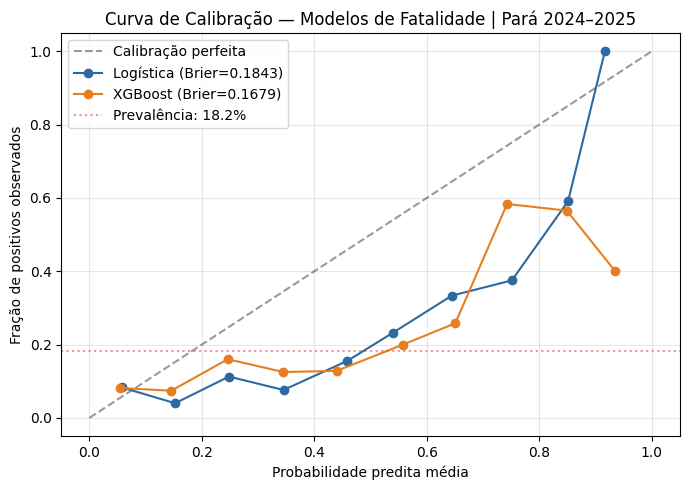

Curva acima da diagonal: modelo subestima o risco (típico com scale_pos_weight)
Curva abaixo: superestima. Diagonal = calibração perfeita.


In [35]:
# ── 5.4  CALIBRAÇÃO — BRIER SCORE + CURVA ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
ax.plot([0,1],[0,1],"k--",alpha=0.4,label="Calibração perfeita")

for nome, proba_m, cor in [
        ("Logística", proba_log, "#2D6A9F"),
        ("XGBoost",   proba_xgb, "#E67E22")]:
    frac_pos, mean_pred = calibration_curve(y_test, proba_m, n_bins=10)
    bs = brier_score_loss(y_test, proba_m)
    ax.plot(mean_pred, frac_pos, marker="o", color=cor,
            label=f"{nome} (Brier={bs:.4f})")

ax.axhline(y=y_test.mean(), color="#E74C3C", linestyle=":",
           alpha=0.6, label=f"Prevalência: {y_test.mean()*100:.1f}%")
ax.set_xlabel("Probabilidade predita média")
ax.set_ylabel("Fração de positivos observados")
ax.set_title("Curva de Calibração — Modelos de Fatalidade | Pará 2024–2025")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/calibracao.png", dpi=120, bbox_inches="tight")
plt.show()
print("Curva acima da diagonal: modelo subestima o risco (típico com scale_pos_weight)")
print("Curva abaixo: superestima. Diagonal = calibração perfeita.")


In [36]:
# ── 5.5  RECALIBRAÇÃO (Platt Scaling) ─────────────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

# Recalibrar XGBoost com Platt scaling (sigmoid)
xgb_cal = CalibratedClassifierCV(
    xgb.XGBClassifier(
        n_estimators=600, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        scale_pos_weight=spw, random_state=42,
        eval_metric="auc", n_jobs=-1, verbosity=0),
    cv=5, method="sigmoid"
)
xgb_cal.fit(X_tr_ohe, y_train)
proba_cal = xgb_cal.predict_proba(X_te_ohe)[:,1]

bs_cal = brier_score_loss(y_test, proba_cal)
auc_cal = roc_auc_score(y_test, proba_cal)

print("="*60)
print("📌 XGBOOST RECALIBRADO (Platt Scaling)")
print("="*60)
print(f"Brier antes: {bs_xgb:.4f}  →  após: {bs_cal:.4f}")
print(f"AUC antes:   {auc_xgb:.4f}  →  após: {auc_cal:.4f}")
print(f"Brier ingênuo: {bs_nv:.4f}")
melhora = "✅ Melhorou" if bs_cal < bs_xgb else "❌ Não melhorou"
print(f"\n{melhora} a calibração.")


📌 XGBOOST RECALIBRADO (Platt Scaling)
Brier antes: 0.1679  →  após: 0.1291
AUC antes:   0.7402  →  após: 0.7437
Brier ingênuo: 0.1488

✅ Melhorou a calibração.


In [37]:
# ── 5.6  ANÁLISE DE THRESHOLD ─────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

def avaliar_thresholds(y_true, proba, thresholds):
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall":    recall_score(y_true, pred, zero_division=0),
            "f1":        f1_score(y_true, pred, zero_division=0),
            "positivos": int(pred.sum()),
        })
    return pd.DataFrame(rows)

ths = np.round(np.linspace(0.10, 0.90, 17), 2)
df_thr = avaliar_thresholds(y_test, proba_cal, ths)

print("📊 Trade-off threshold × métricas (XGBoost calibrado):")
display(df_thr.sort_values("f1", ascending=False).head(8))

melhor = df_thr.loc[df_thr["f1"].idxmax()]
print(f"\n✅ Melhor F1: t={melhor['threshold']:.2f} | "
      f"precision={melhor['precision']:.3f} | recall={melhor['recall']:.3f} | "
      f"F1={melhor['f1']:.3f}")
print("Threshold operacional: escolher com base no custo de falso negativo vs falso positivo.")


📊 Trade-off threshold × métricas (XGBoost calibrado):


,threshold,precision,recall,f1,positivos
3,0.25,0.428571,0.541667,0.478528,91
4,0.30,0.555556,0.416667,0.476190,54
2,0.20,0.348837,0.625000,0.447761,129
1,0.15,0.285714,0.750000,0.413793,189
0,0.10,0.207430,0.930556,0.339241,323
5,0.35,0.531250,0.236111,0.326923,32
6,0.40,0.764706,0.180556,0.292135,17
7,0.45,0.500000,0.013889,0.027027,2



✅ Melhor F1: t=0.25 | precision=0.429 | recall=0.542 | F1=0.479
Threshold operacional: escolher com base no custo de falso negativo vs falso positivo.


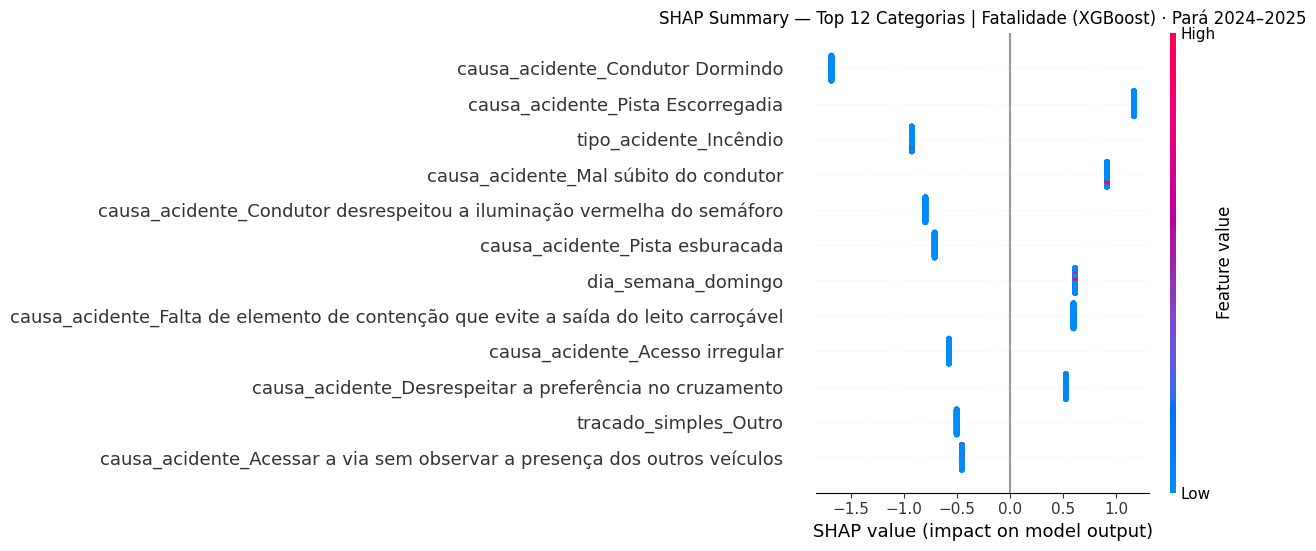


SHAP explica o MODELO PREDITIVO — não implica causalidade.
Sinais contraintuitivos refletem padrões do dataset, não ausência de risco real.


In [38]:
# ── 5.7  SHAP SUMMARY PLOT ────────────────────────────────────────────────────
import shap

ohe_fit    = clf_log.named_steps["prep"].named_transformers_["cat"]
feat_names = ohe_fit.get_feature_names_out(features_pred)

X_shap = X_te_ohe
if hasattr(X_shap, "toarray"):
    X_shap = X_shap.toarray()

rng    = np.random.RandomState(42)
idx    = rng.choice(X_shap.shape[0], size=min(1500, X_shap.shape[0]), replace=False)
X_samp = X_shap[idx]

explainer = shap.TreeExplainer(model_xgb)
sv = explainer.shap_values(X_samp)
if isinstance(sv, list): sv = sv[1]

imp = np.mean(np.abs(sv), axis=0)
top = np.argsort(imp)[::-1][:12]

plt.figure(figsize=(18,6))
shap.summary_plot(
    sv[:,top], X_samp[:,top],
    feature_names=np.array(feat_names)[top],
    max_display=12, plot_type="dot", show=False)
plt.title("SHAP Summary — Top 12 Categorias | Fatalidade (XGBoost) · Pará 2024–2025")
plt.gcf().subplots_adjust(left=0.44, right=0.96, top=0.88, bottom=0.15)
plt.show()
print()
print("SHAP explica o MODELO PREDITIVO — não implica causalidade.")
print("Sinais contraintuitivos refletem padrões do dataset, não ausência de risco real.")


---
## 6. Resumo Consolidado — Notebook 02

| Eixo | Método | Resultado Principal |
|------|--------|---------------------|
| **Ordinal** | POM (logit proporcional) | OR cumulativos para 4 níveis de severidade |
| **Multinível** | GLMM Binomial (efeito BR) | ICC 14% · BLUPs por rodovia · erros-padrão corrigidos |
| **Hotspot** | Teste binomial + Bonferroni/FDR | Trechos com significância estatística e risco relativo |
| **Preditivo** | XGBoost + Platt + SHAP | AUC ~0,74 · calibração corrigida · top features |

---

### Declaração de Transparência Metodológica

- **Inferência vs. Predição:** Seções 2–4 são o eixo inferencial principal. Seção 5 é complemento preditivo.
- **Causalidade:** OR e BLUPs são associações condicionais. Nenhum resultado implica causalidade.
- **Calibração:** Brier Score avalia qualidade das probabilidades absolutas (não apenas ranking). Platt Scaling corrige descalibração.
- **Hotspot:** Teste binomial controla comparações múltiplas (Bonferroni conservador ou FDR como alternativa).
- **Limitações:** N=1.977 limita poder para trechos raros; ausência de dados de exposição (volume de tráfego); subnotificação em causas como álcool.

### Próximos Passos

1. Incorporar **dados de Volume Médio Diário (VMD)** do DNIT para taxa por exposição
2. **Regressão geograficamente ponderada (GWR)** — efeitos dos fatores variam por região?
3. **Interações** no modelo ordinal: `uso_solo × tracado_via`, `br × fase_dia`
4. **Série temporal mais longa** (2020–2025) para tendência com maior poder estatístico
